# Robustness & Measurement Uncertainty

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.style import setup_style
from src.statistics import (
    monte_carlo_stratified_teff,
    mc_uncertainty_propagation,
    weighted_median_contrast,
    vsini_error,
)
from src.plotting import (
    plot_mv_weight_distributions,
    plot_teff_strata_boxplots,
    plot_robustness_comparison,
    plot_error_maps,
)

setup_style(fontsize=11)

COLORS = {"F": "#2166ac", "G": "#d68d4d", "ALL": "#404040"}

ROOT = Path("../")
FIG_DIR = ROOT / "figures"
R_CUT = 80.0  # cavity boundary [pc]
SEED = 42

## 2. Load data

In [3]:
df_F = pd.read_csv(ROOT / "data" / "processed" / "gcs-Fstars-complete.csv")
df_G = pd.read_csv(ROOT / "data" / "processed" / "gcs-Gstars-complete.csv")
df_all = pd.read_csv(ROOT / "data" / "processed" / "gcs-allstars-complete.csv")

n_in = (df_all["R_xy"] <= R_CUT).sum()
n_out = (df_all["R_xy"] > R_CUT).sum()

print(f"F: {len(df_F):,}   G: {len(df_G):,}   All: {len(df_all):,}")
print(f"Cavity (R <= {R_CUT:.0f} pc): {n_in:,} | Shell (R > {R_CUT:.0f} pc): {n_out:,}")

F: 1,475   G: 1,298   All: 2,773
Cavity (R <= 80 pc): 2,440 | Shell (R > 80 pc): 333


# MC uncertainty propagation vs. demographic null

In [4]:
print("Running T_eff-stratified permutation test (N=10 000) ...")
res_strat = monte_carlo_stratified_teff(
    df_all, iterations=10_000, r_cut=R_CUT, n_bins=10, seed=SEED
)
null_dist = res_strat["null_dist"]
print(
    f"  Demographic null:  mu = {null_dist.mean():.2f}  sigma = {null_dist.std():.2f} km/s"
)
print(f'  Observed Delta_v  = {res_strat["obs_diff"]:.2f} km/s')
print(f'  Z-score           = {res_strat["z_score"]:.2f}')

Running T_eff-stratified permutation test (N=10 000) ...
  Demographic null:  mu = 10.89  sigma = 0.81 km/s
  Observed Delta_v  = 13.46 km/s
  Z-score           = 3.18


In [5]:
print("Running MC uncertainty propagation (N=10 000) ...")
obs_mc_dist = mc_uncertainty_propagation(df_all, n_mc=10_000, r_cut=R_CUT, seed=SEED)
mu_null = float(null_dist.mean())
mu_obs = float(obs_mc_dist.mean())
sig_null = float(null_dist.std())
sig_obs = float(obs_mc_dist.std())

delta_v_phys = mu_obs - mu_null
z_robust = delta_v_phys / np.sqrt(sig_obs**2 + sig_null**2)

print(f"  Observed + errors: mu = {mu_obs:.2f}  sigma = {sig_obs:.2f} km/s")
print(f"  Delta_v_phys = {delta_v_phys:.2f} km/s")
print(f"  Z_robust = {z_robust:.2f} sigma")

Running MC uncertainty propagation (N=10 000) ...
  Observed + errors: mu = 13.45  sigma = 0.16 km/s
  Delta_v_phys = 2.56 km/s
  Z_robust = 3.10 sigma


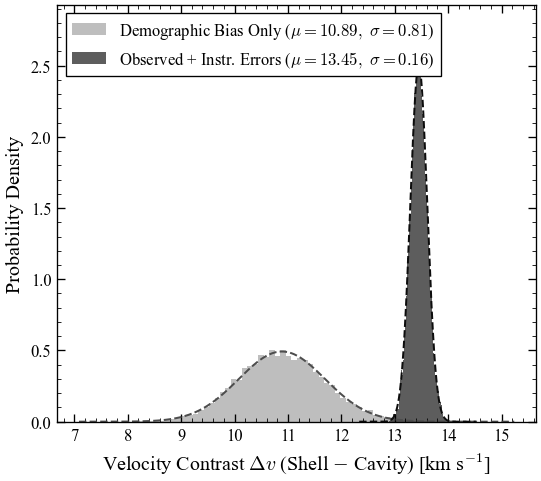


The ~2.6 km/s residual is 3.1sigma above measurement noise; the detection is NOT washed out by instrumental uncertainties.


In [6]:
fig18, ax18 = plot_robustness_comparison(
    null_dist, obs_mc_dist, mu_null=mu_null, mu_obs=mu_obs, figsize=(4.5, 4)
)
fig18.savefig(FIG_DIR / "robustness_uncertainty.pdf")
plt.show()

print(
    f"\nThe ~{delta_v_phys:.1f} km/s residual is {z_robust:.1f}sigma above "
    "measurement noise; the detection is NOT washed out by instrumental uncertainties."
)

# Mean instrumental error maps

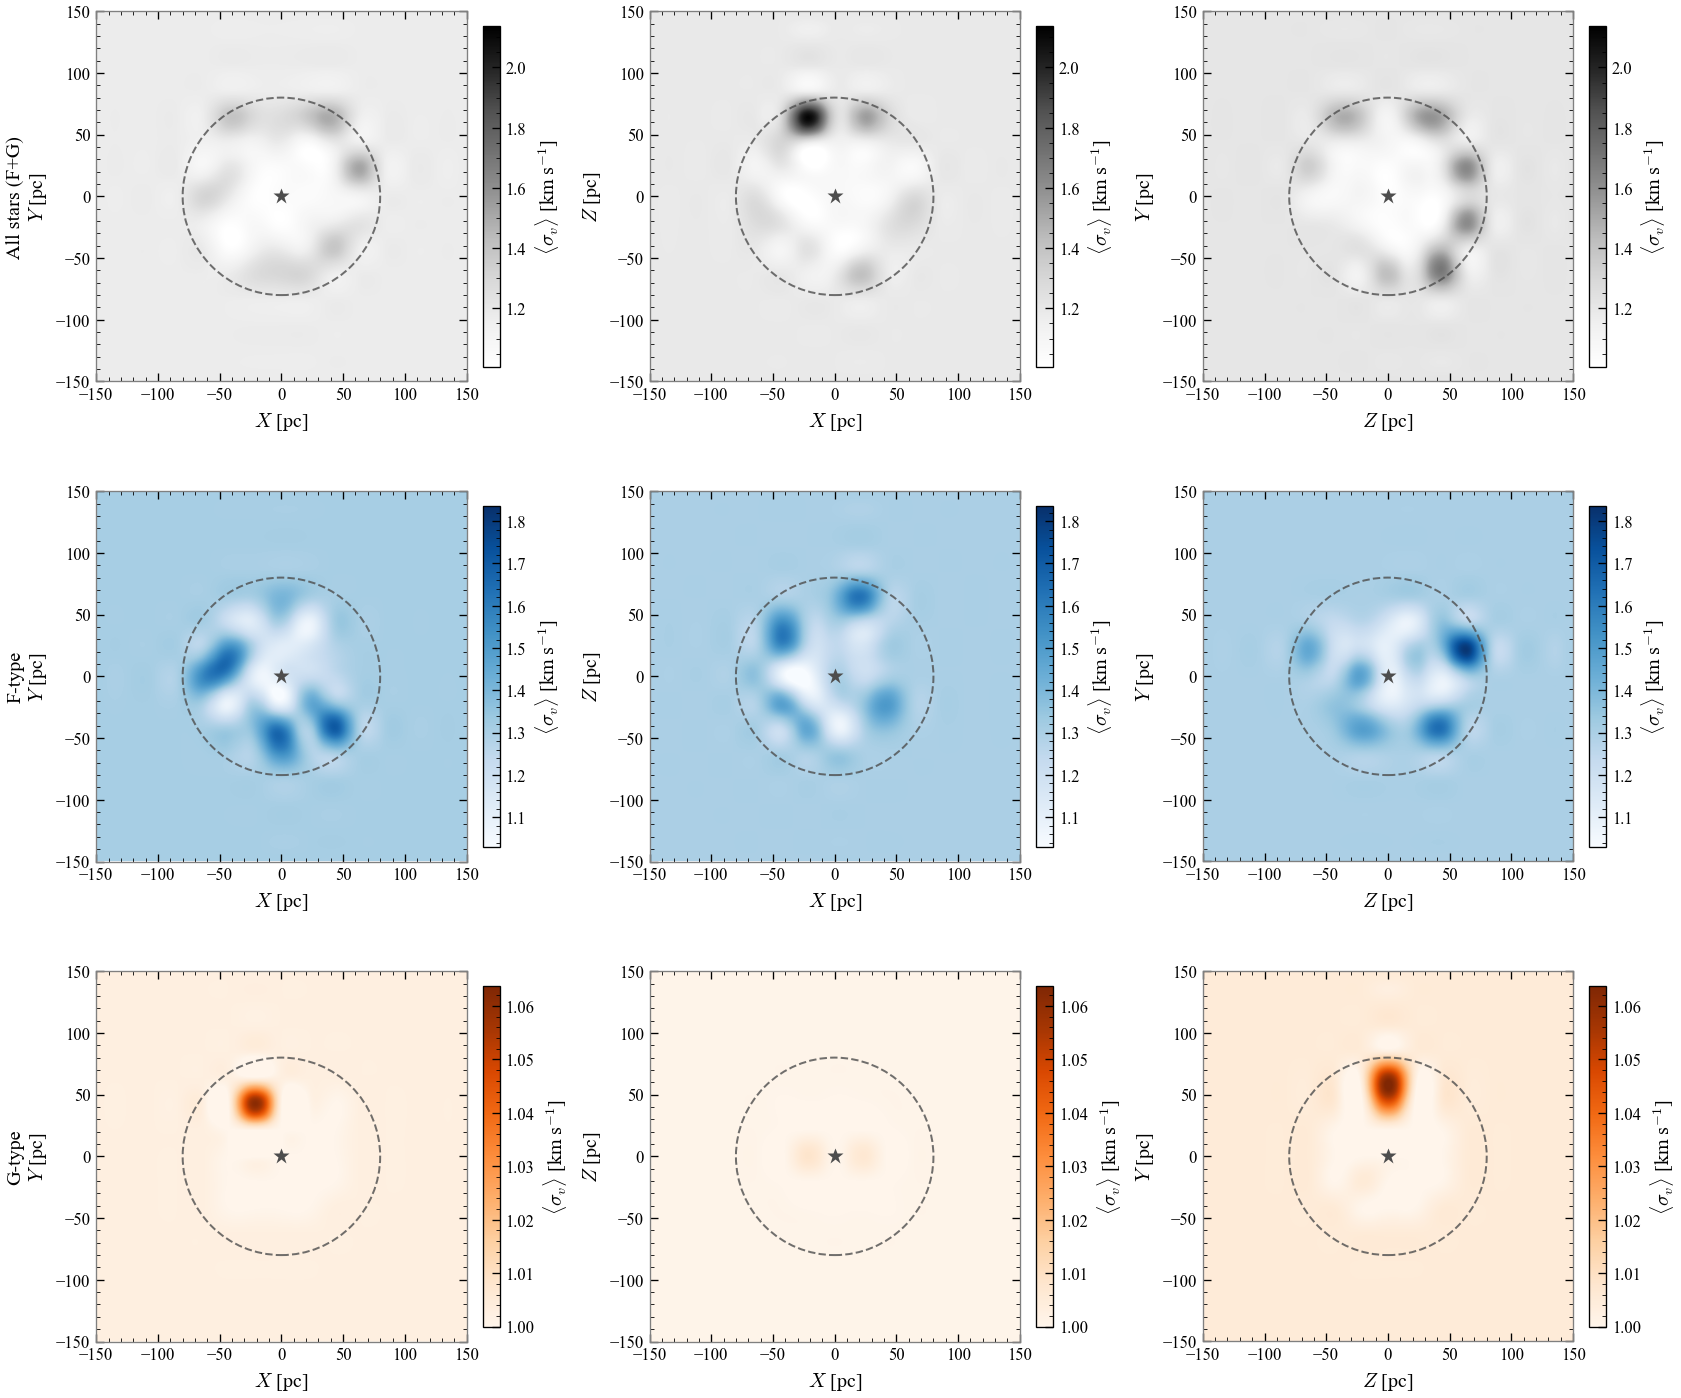

In [7]:
fig19, axes19 = plot_error_maps(
    df_all, df_F, df_G, ul=150.0, tc=20.0, min_count=20, r_cut=R_CUT
)
fig19.savefig(FIG_DIR / "error_maps.pdf")
plt.show()

In [8]:
# Quantify: compare mean sigma_v inside vs. outside the cavity boundary
print("Mean <sigma_v> inside vs. outside the 80 pc cavity boundary")
print("-" * 55)
for label, df in [("All (F+G)", df_all), ("F-type", df_F), ("G-type", df_G)]:
    r = df["R_xy"].values
    sigma = vsini_error(df["vsini"].values)
    w = df["w_vmax"].values

    in_mask = r <= R_CUT
    out_mask = r > R_CUT

    sig_in = np.average(sigma[in_mask], weights=w[in_mask])
    sig_out = np.average(sigma[out_mask], weights=w[out_mask])

    print(
        f"  {label:<12}  cavity: {sig_in:.3f} km/s  shell: {sig_out:.3f} km/s  "
        f"ratio: {sig_out/sig_in:.3f}"
    )

Mean <sigma_v> inside vs. outside the 80 pc cavity boundary
-------------------------------------------------------
  All (F+G)     cavity: 1.103 km/s  shell: 2.108 km/s  ratio: 1.911
  F-type        cavity: 1.300 km/s  shell: 2.558 km/s  ratio: 1.968
  G-type        cavity: 1.003 km/s  shell: 1.102 km/s  ratio: 1.099
